# ARoF DPD-NN

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado"
file_path    = project_path + r"\DPD"
sys.path.append(project_path)

In [689]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.constants               import pi
from scipy.signal                  import firwin, welch
from tqdm.notebook                 import tqdm
from tabulate                      import tabulate

from optic_private.comm.metrics    import calcEVM
from optic_private.dsp.core        import lowPassFIR, calcACLR
from optic_private.utils           import parameters, lin2dB, dBm2W

from optic_private.torchModulation import modulateGray, demodulateGray, grayMapping
from optic_private.torchMetrics    import fastBERcalc, calcMI, signal_power, papr
from optic_private.torchDSP        import upsample, firFilter, pnorm, hilbert, decimate, finddelay
from optic_private.torchModels     import mzm, linearFiberChannel, photodiode, powerAmplifier
from optic_private.torchOFDM       import modulateOFDM, demodulateOFDM

import torch as th
from torch import nn
from torch.utils.data import Dataset, DataLoader
from optic_private.torchUtils import memoryLessDataSet, MLP, train_model, test_model, slidingWindowDataSet, fitFilterNN

from DPD_utils.NN_tools import NN_training
from DPD_utils.MP_tools import calcSNR_per_carrier

#import logging as logg
#logg.basicConfig(level=logg.WARN, format='%(message)s', force=True)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [734]:
device = 'cuda'
includeMemory = True

# Parâmetros de modulação
modOrder = 64
modType  = 'qam'
Rb = 5e9    
SpS = 64

# OFDM signal parameters
paramOFDM = parameters()
paramOFDM.Nfft = 1024
paramOFDM.Np   = 64
paramOFDM.G    = 32
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft-1, paramOFDM.Np, dtype=np.int64) # Pilot subcarriers
Ns = paramOFDM.Nfft - paramOFDM.Np     # Núm. de subportadoras de informação

Rs = Rb / ( Ns/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
batchSize = 1000//(int(paramOFDM.Nfft/128))
bits = th.randint(2, size = (batchSize*(Ns - 1), int(np.log2(modOrder))), dtype = th.float32, device = device)

symbTx  = modulateGray(bits.view(-1,).type(th.int64), modOrder, modType)    
symbTx  = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [735]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = th.arange(0, len(sigTx), dtype=th.float64, device=device)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [736]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ns}'],
         ['Num. port. piloto', 'Np', f'{paramOFDM.Np}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 58.67 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.92 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [ ]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi/2
paramMZM.Pin_OF = 15

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 30
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 10e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

#### 2.1 Sinal RF

In [738]:
sigTx_RF = th.real( sigTx * th.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF = np.sqrt(dBm2W(paramRF.Pin_RF))*pnorm(sigTx_RF)

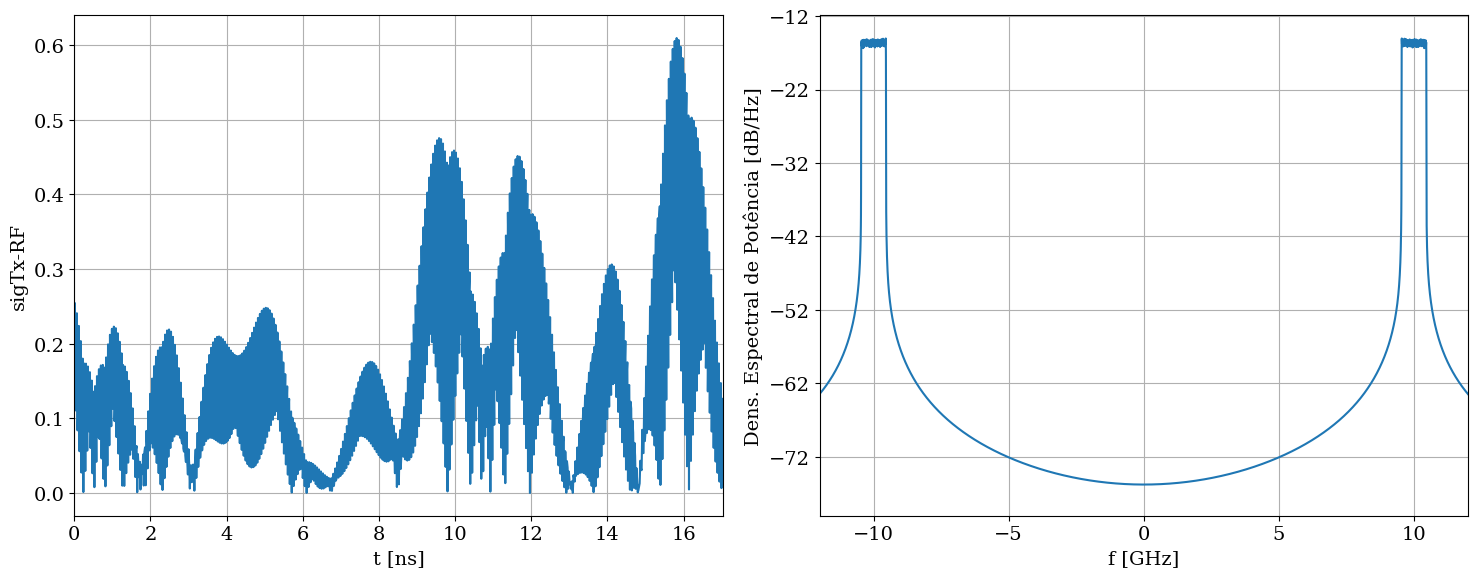

In [739]:

indx = np.arange(0, 1000)

fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigTx_RF.cpu().numpy()[indx]))
axs[1].psd(sigTx_RF.detach().cpu().numpy(), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t.cpu().numpy()[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("sigTx-RF")
axs[0].grid()

axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-80)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.2 Sinal óptico

In [740]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*th.ones(sigTx_RF.shape, device=device)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = th.tensor(firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)).to(device)
sigTxo  = th.sqrt(signal_power(sigTxo))*pnorm(firFilter(sigTxo, hopt_tx))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

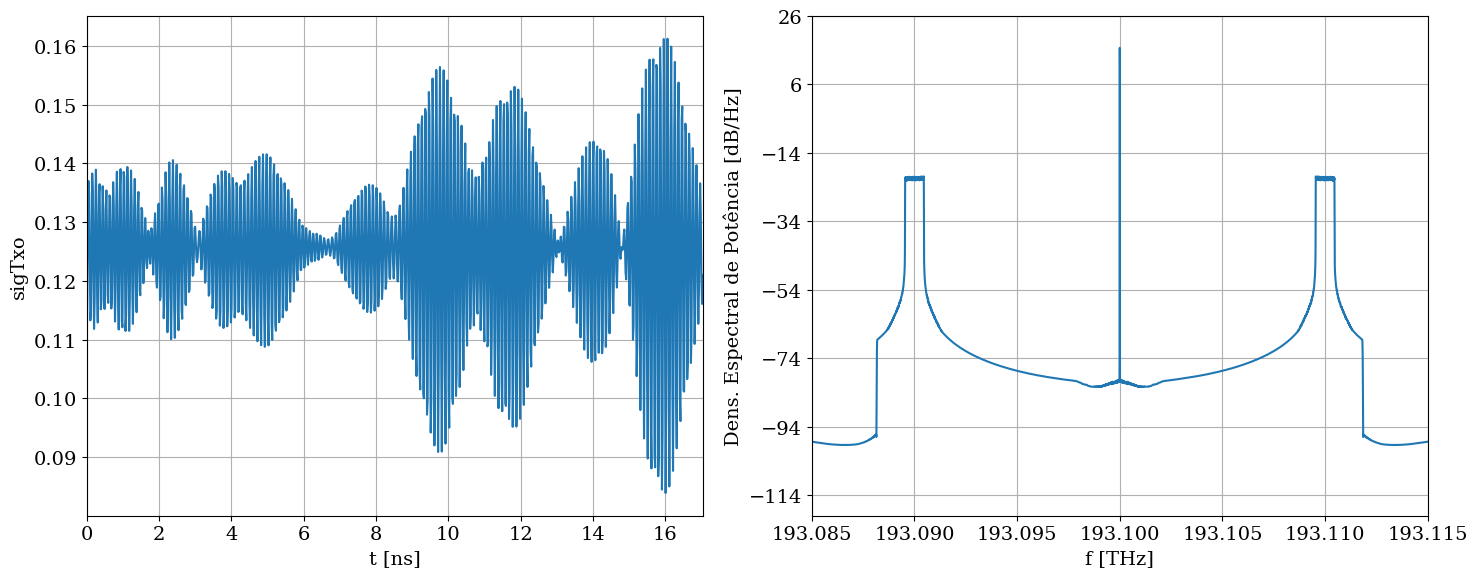

In [741]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t[indx].cpu().numpy()*1e9, np.abs(sigTxo.cpu().numpy()[indx]))
axs[1].psd((th.abs(sigTxo)**2).detach().cpu().numpy(), Fs = Fs/1e12, Fc = paramChannel.Fc/1e12, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t.cpu().numpy()[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("sigTxo")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-0.015 + paramChannel.Fc/1e12, 0.015 + paramChannel.Fc/1e12)
axs[1].set_ylim(-120)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.3 Sinal elétrico (fotocorrente)

In [742]:
I_Rx = photodiode(sigRxo, paramPD)
I_Rx = pnorm(I_Rx)
I_Rx -= I_Rx.mean()

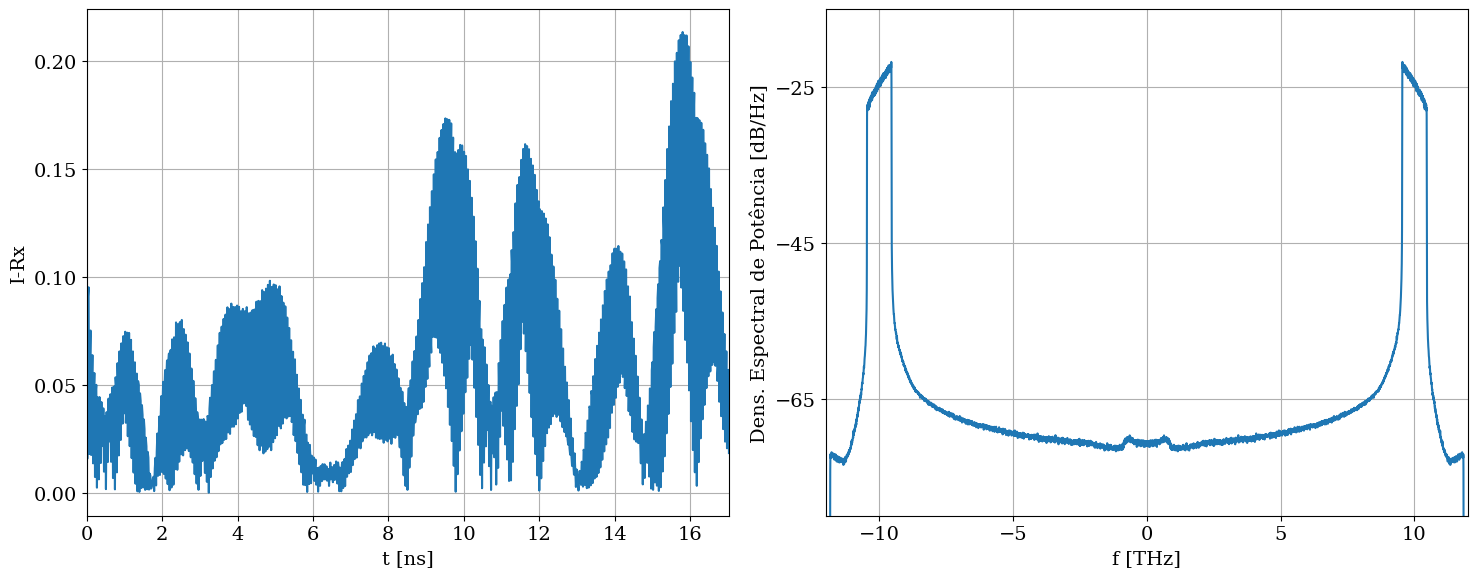

In [743]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(I_Rx.cpu().numpy()[indx]))
axs[1].psd(I_Rx.detach().cpu().numpy(), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t.cpu().numpy()[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-Rx")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
axs[1].set_ylim(-80)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.4 Sinal elétrico pós-FPF

In [744]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = th.tensor(firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)).to(device)

I_RF = firFilter(hbp_RF, I_Rx)

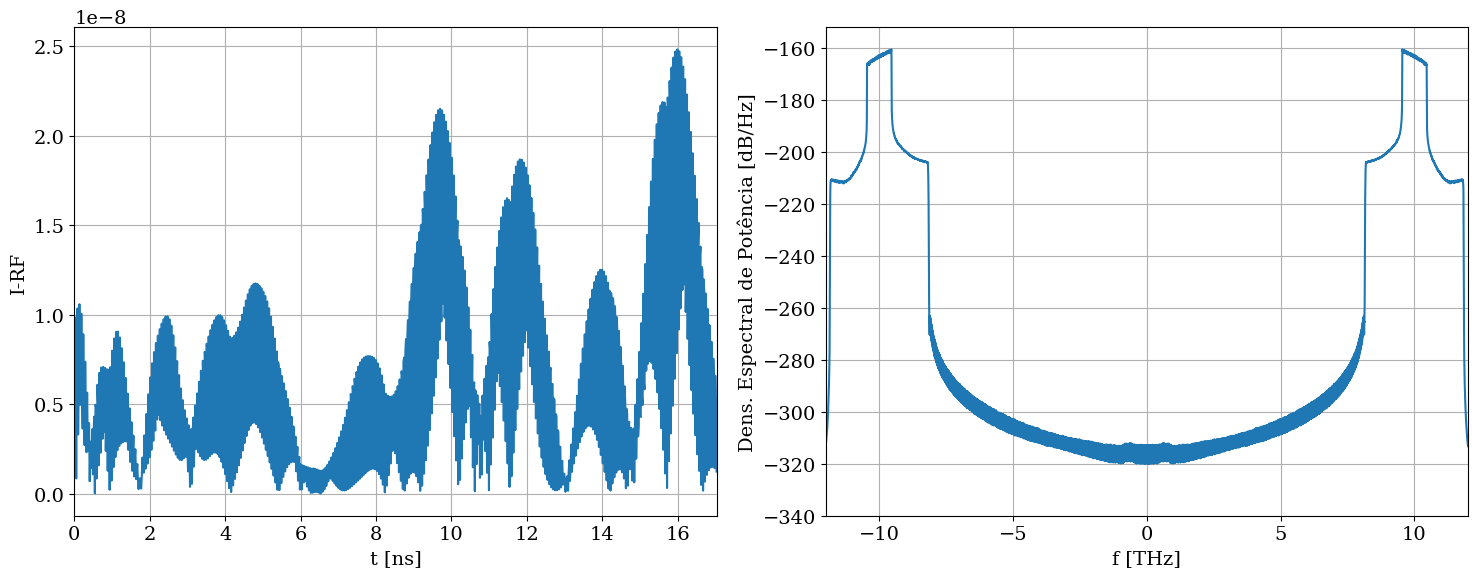

In [745]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(I_RF.cpu().numpy()[indx]))
axs[1].psd(I_RF.detach().cpu().numpy(), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t.cpu().numpy()[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("I-RF")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-paramRF.fc_e/1e9 - 2, paramRF.fc_e/1e9 + 2)
#axs[1].set_ylim(-80)
axs[1].grid(True)

plt.tight_layout()
plt.show()

#### 2.5 Sinal elétrico pós-PA

In [746]:
sigRx = hilbert(I_RF)*th.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx = np.sqrt(dBm2W(paramRF.Pin_PA))*pnorm(sigRx)
sigRx = powerAmplifier(sigRx)

sigRx_PA = sigRx.clone().detach()

numtaps = 4096

hlp = th.tensor(firwin(numtaps, Rs/1.5, fs = Fs)).to(device)
sigRx = firFilter(hlp, sigRx)

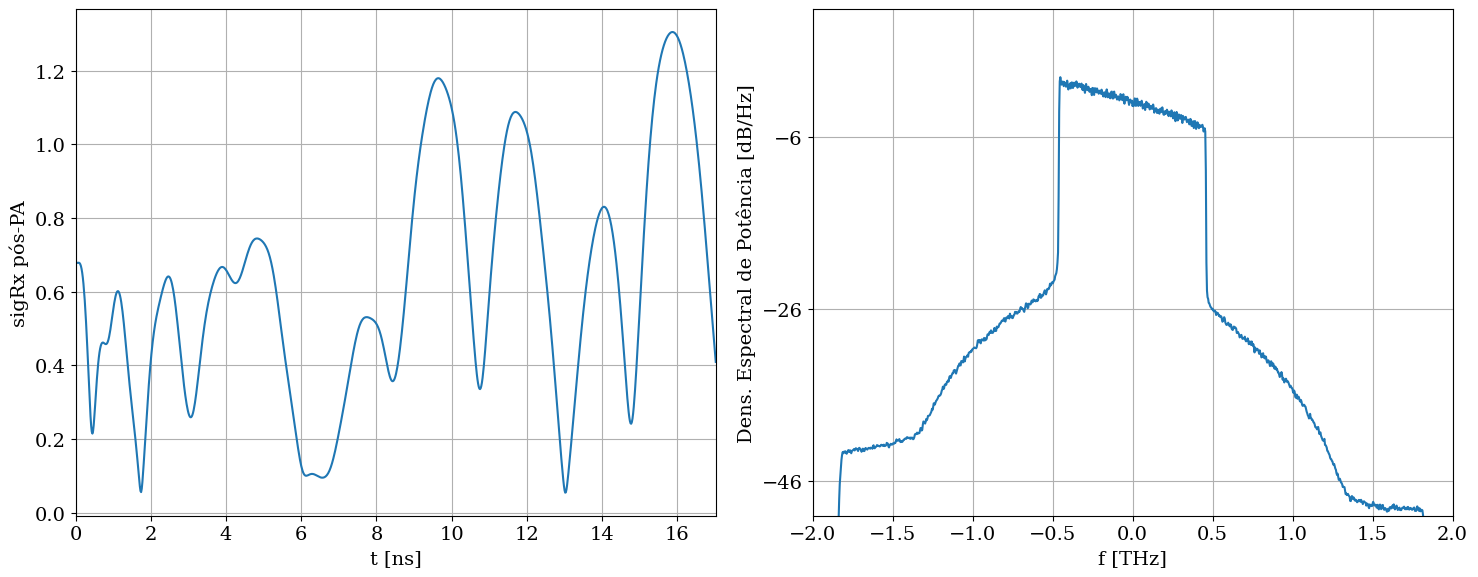

In [747]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRx_PA.cpu().numpy()[indx]))
axs[1].psd(sigRx_PA.detach().cpu().numpy(), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided')

axs[0].set_xlim(0, t.cpu().numpy()[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].set_ylabel("sigRx pós-PA")
axs[0].grid()

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-50)
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [748]:
delay = finddelay(sigRx, sigTx)
sigRx = th.roll(sigRx, -delay)

rot = th.mean(sigTx/sigRx)
sigRx = rot/th.abs(rot)*sigRx

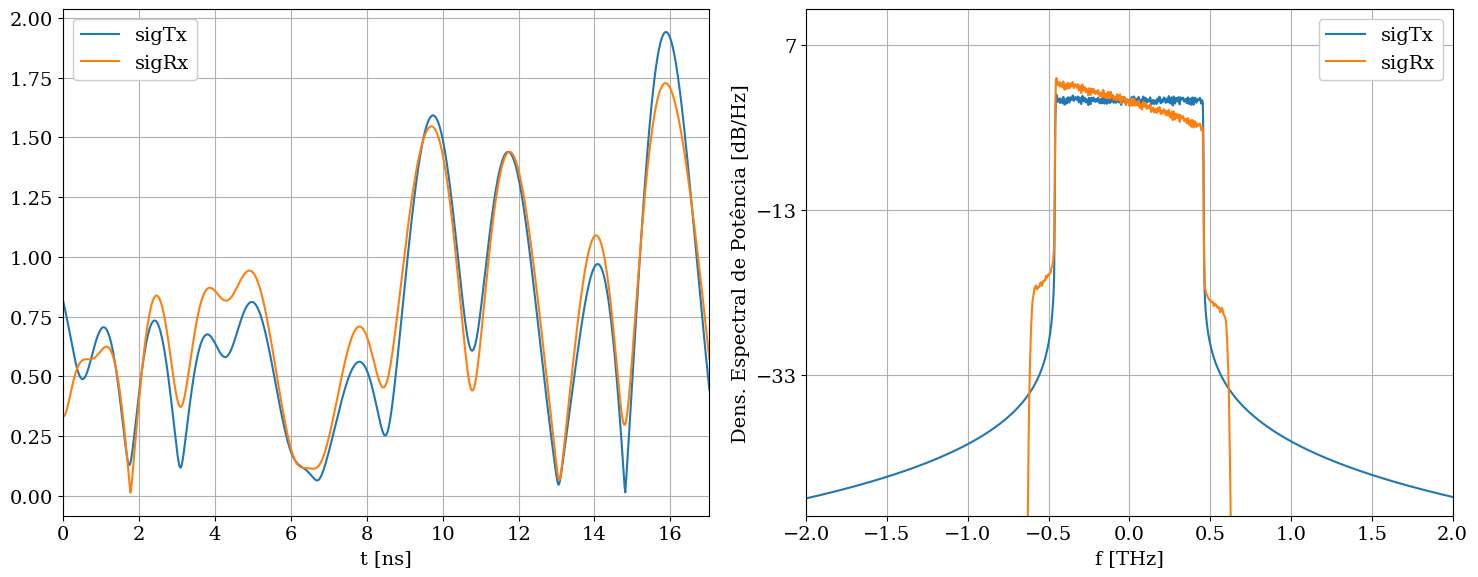

In [749]:

indx = np.arange(0, 1000)
fig, axs = plt.subplots(1, 2, figsize = (15, 6))

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(pnorm(sigTx).cpu().numpy()[indx]), label = "sigTx")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(pnorm(sigRx).cpu().numpy()[indx]), label = "sigRx")

axs[1].psd(pnorm(sigTx).detach().cpu().numpy(), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "sigTx")
axs[1].psd(pnorm(sigRx).detach().cpu().numpy(), Fs = Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "sigRx")

axs[0].set_xlim(0, t.cpu().numpy()[indx][-1]*1e9)
axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1)

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1)

plt.tight_layout()
plt.show()

#### 2.6 Performance

In [750]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx, paramDec).ravel()
symbRx = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00786 
SNR = 20.425 dB


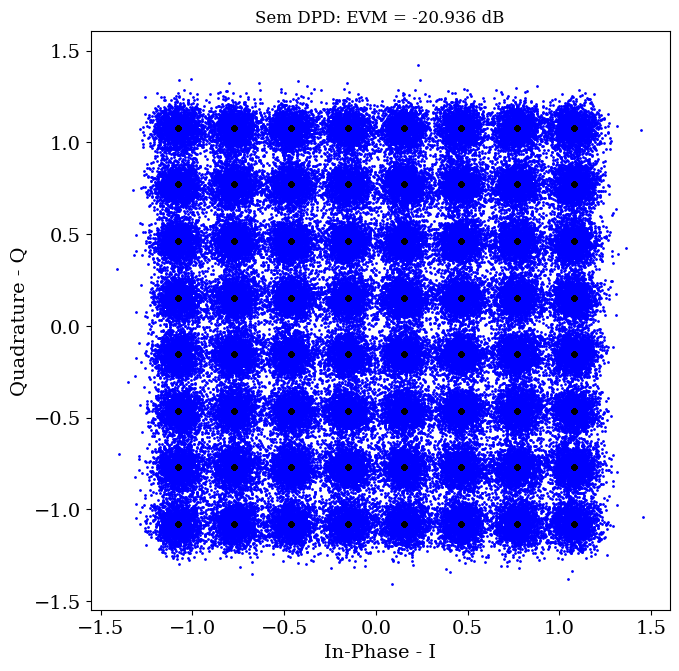

In [751]:
discard = 500
index = th.arange(discard, len(symbTx) - discard)
BER, SER, SNR = fastBERcalc(symbRx[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx.detach().cpu().numpy(), modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx.real.cpu().numpy(), symbRx.imag.cpu().numpy(), "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real.cpu().numpy(), symbTx.imag.cpu().numpy(), "o", color = "k", ms = 3, label = "SymbTx")
axs.set_title(f"Sem DPD: EVM = {EVM[0]:.3f} dB", fontsize = 12)
axs.set_ylabel("Quadrature - Q")
axs.set_xlabel("In-Phase - I")
plt.axis("square")
plt.tight_layout()

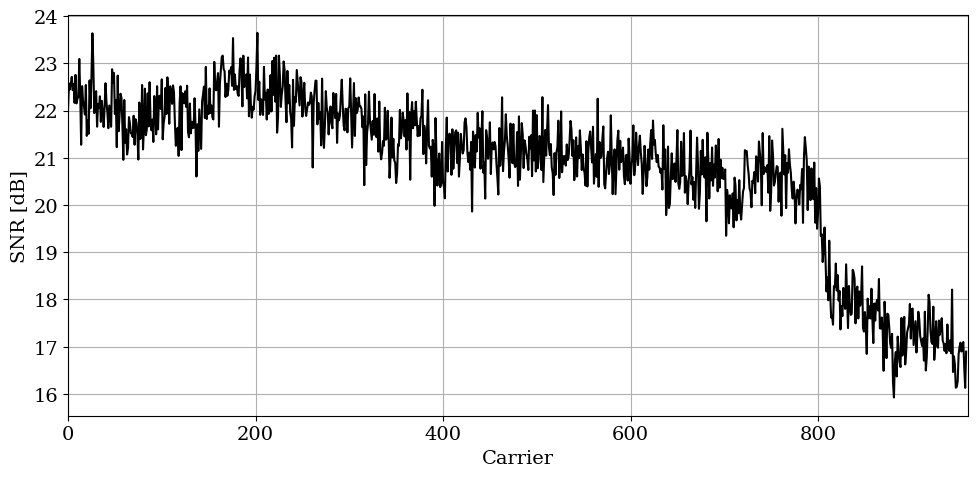

In [752]:
SNR_per_carrier = calcSNR_per_carrier(symbTx.detach().cpu().numpy(), symbRx.detach().cpu().numpy(), Ns - 1)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(SNR_per_carrier, color = "k")
axs.set_xlim(0, Ns)
axs.set_ylabel("SNR [dB]")
axs.set_xlabel("Carrier")
axs.grid()
plt.tight_layout()

### 3 Identificação do canal

In [753]:
SpS_nn = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_nn

hlp = th.tensor(firwin(numtaps, SpS_nn*Rs/2, fs = Fs)).to(device)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec)
sigIn  = decimate(pnorm(firFilter(hlp, sigRx_PA)), paramDec).type(th.complex64)

sigRef = pnorm(sigRef).flatten()
sigIn  = pnorm(sigIn).flatten()

In [754]:
delay = finddelay(sigIn, sigRef)
sigIn = th.roll(sigIn, -delay)

rot = th.mean(sigRef/sigIn)
sigIn = rot/th.abs(rot)*sigIn

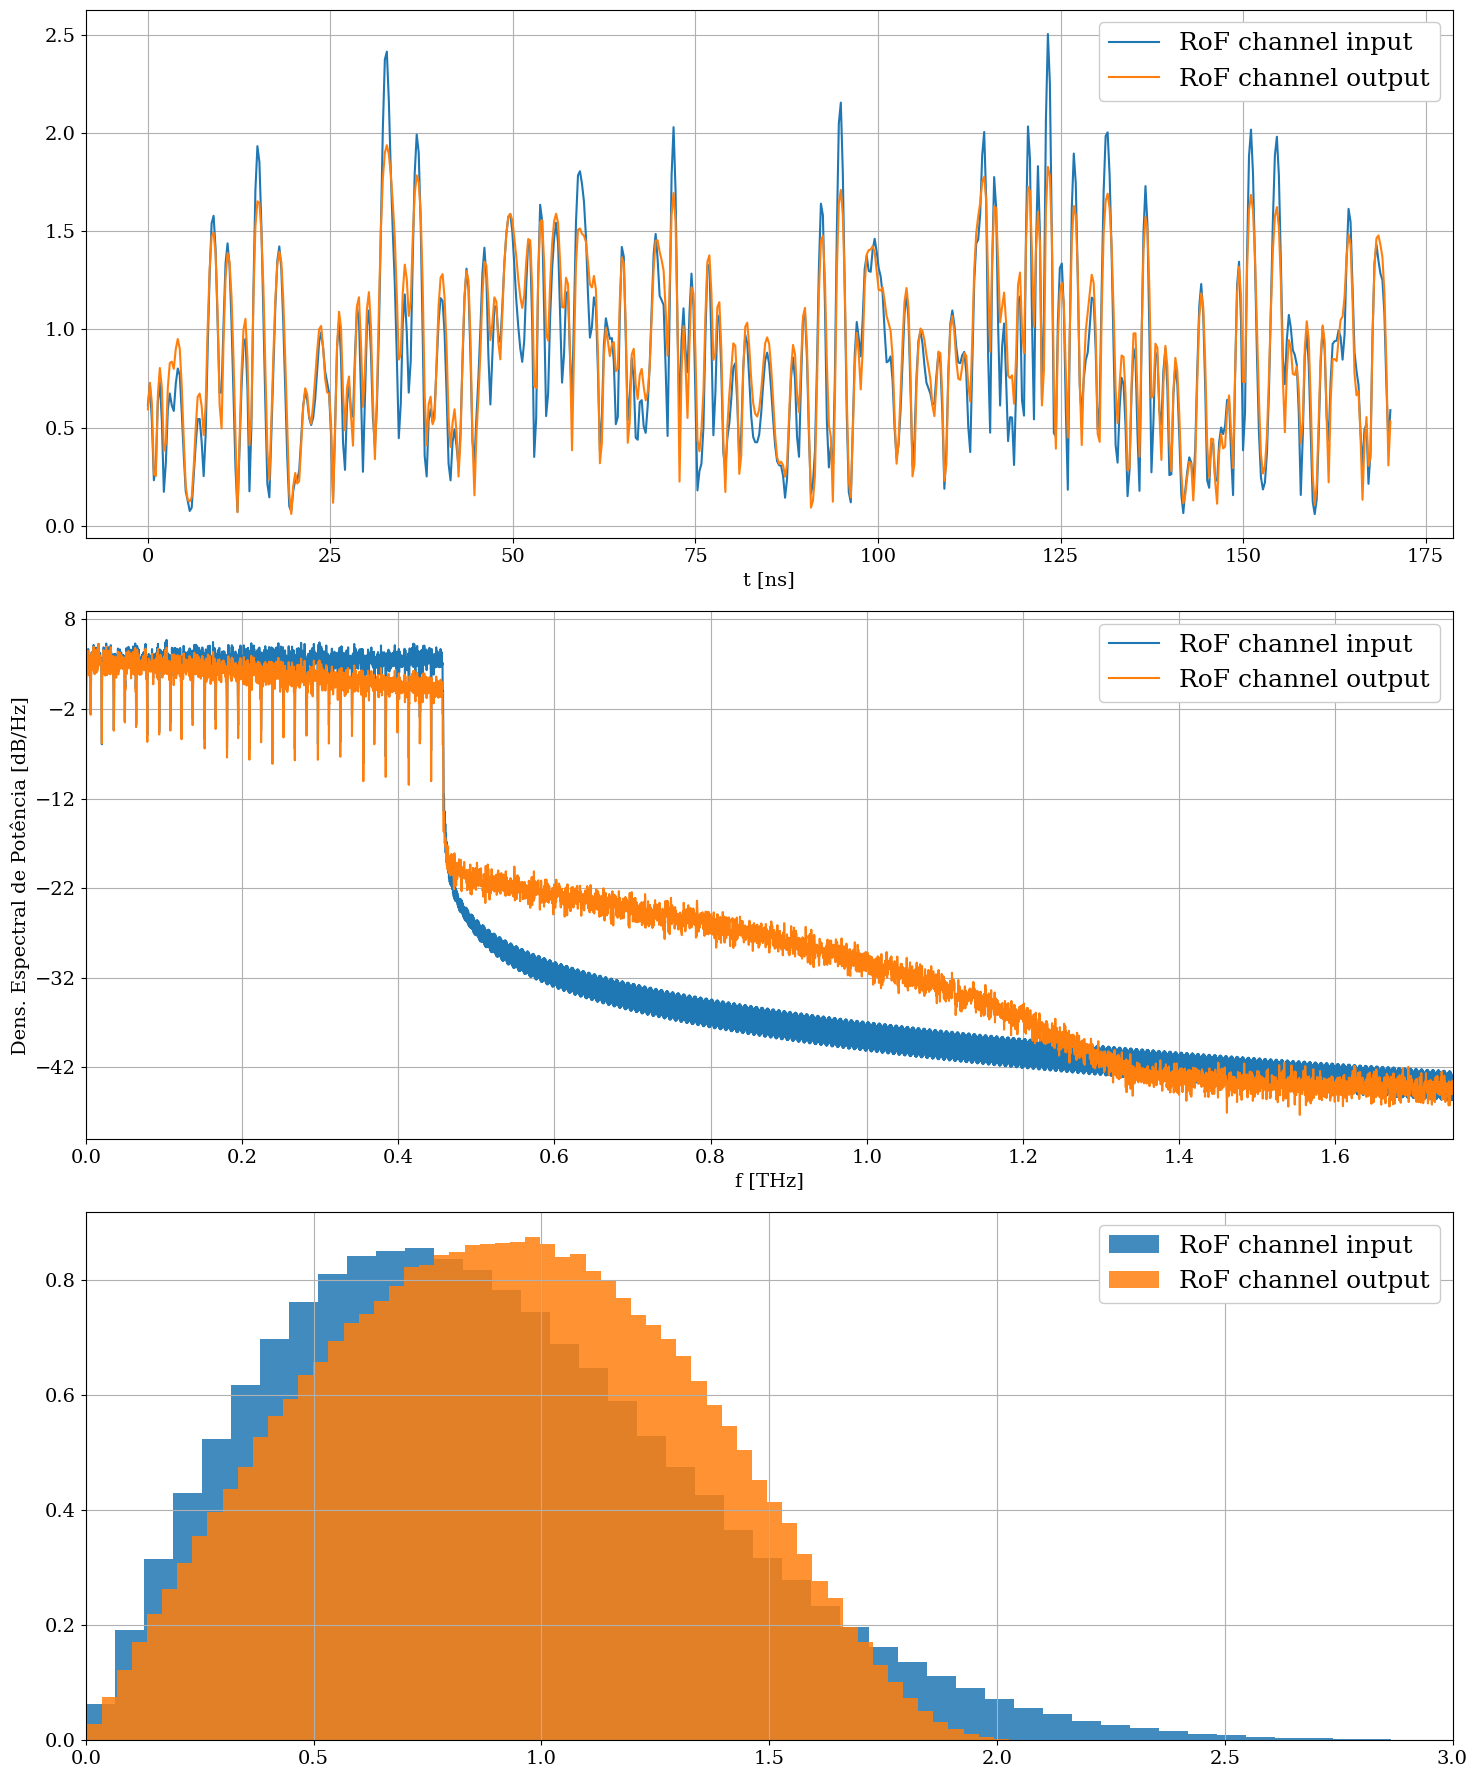

In [755]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), label = "RoF channel output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'onesided', label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'onesided', label = "RoF channel output")

axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(0, 1.75)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

In [1094]:
paramTrain = parameters()

N = 200000
paramTrain.num_feat = 2
paramTrain.N1 = 10
paramTrain.N2 = 150

paramTrain.divByL = 25
paramTrain.trainTestFrac = 0.75
paramTrain.batch_size = 100
paramTrain.shuffle = False
paramTrain.includeMemory = includeMemory
paramTrain.Ntaps = 8
paramTrain.augment = False

paramTrain.device = device
paramTrain.lr = 6e-4
paramTrain.epochs = 500
paramTrain.activation = "relu"
paramTrain.pgrsBar = True
paramTrain.directLearn = False

RoFChannel_model, trainLoss, testLoss = NN_training(sigRef[0:N], sigIn[0:N], paramTrain)

  0%|          | 0/500 [00:00<?, ?it/s]

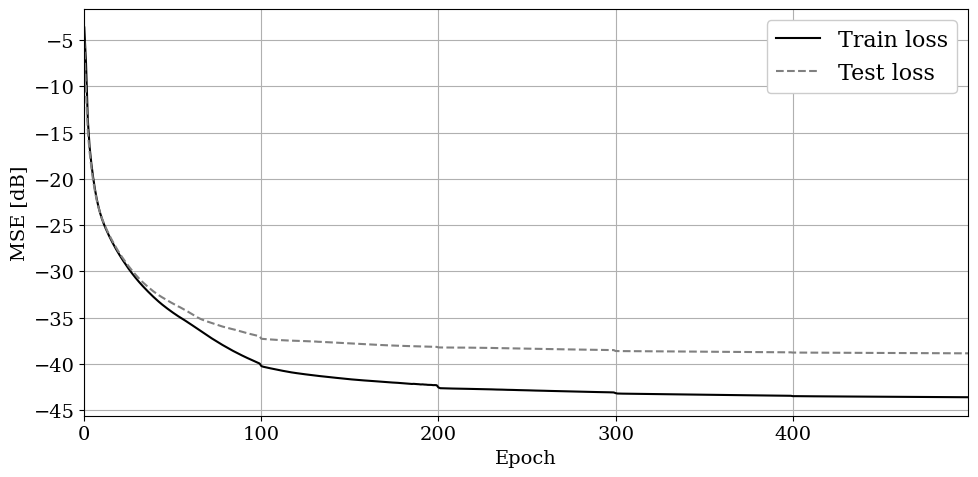

In [1095]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramTrain.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [1096]:
if includeMemory:
    sig_nn = fitFilterNN(sigRef, RoFChannel_model, paramTrain.Ntaps, 1, 4000, augment = paramTrain.augment)
else:
    with th.no_grad():
        sig_nn = th.view_as_complex(RoFChannel_model(th.view_as_real(sigRef).to(th.float32)))

MSE = -37.936 dB


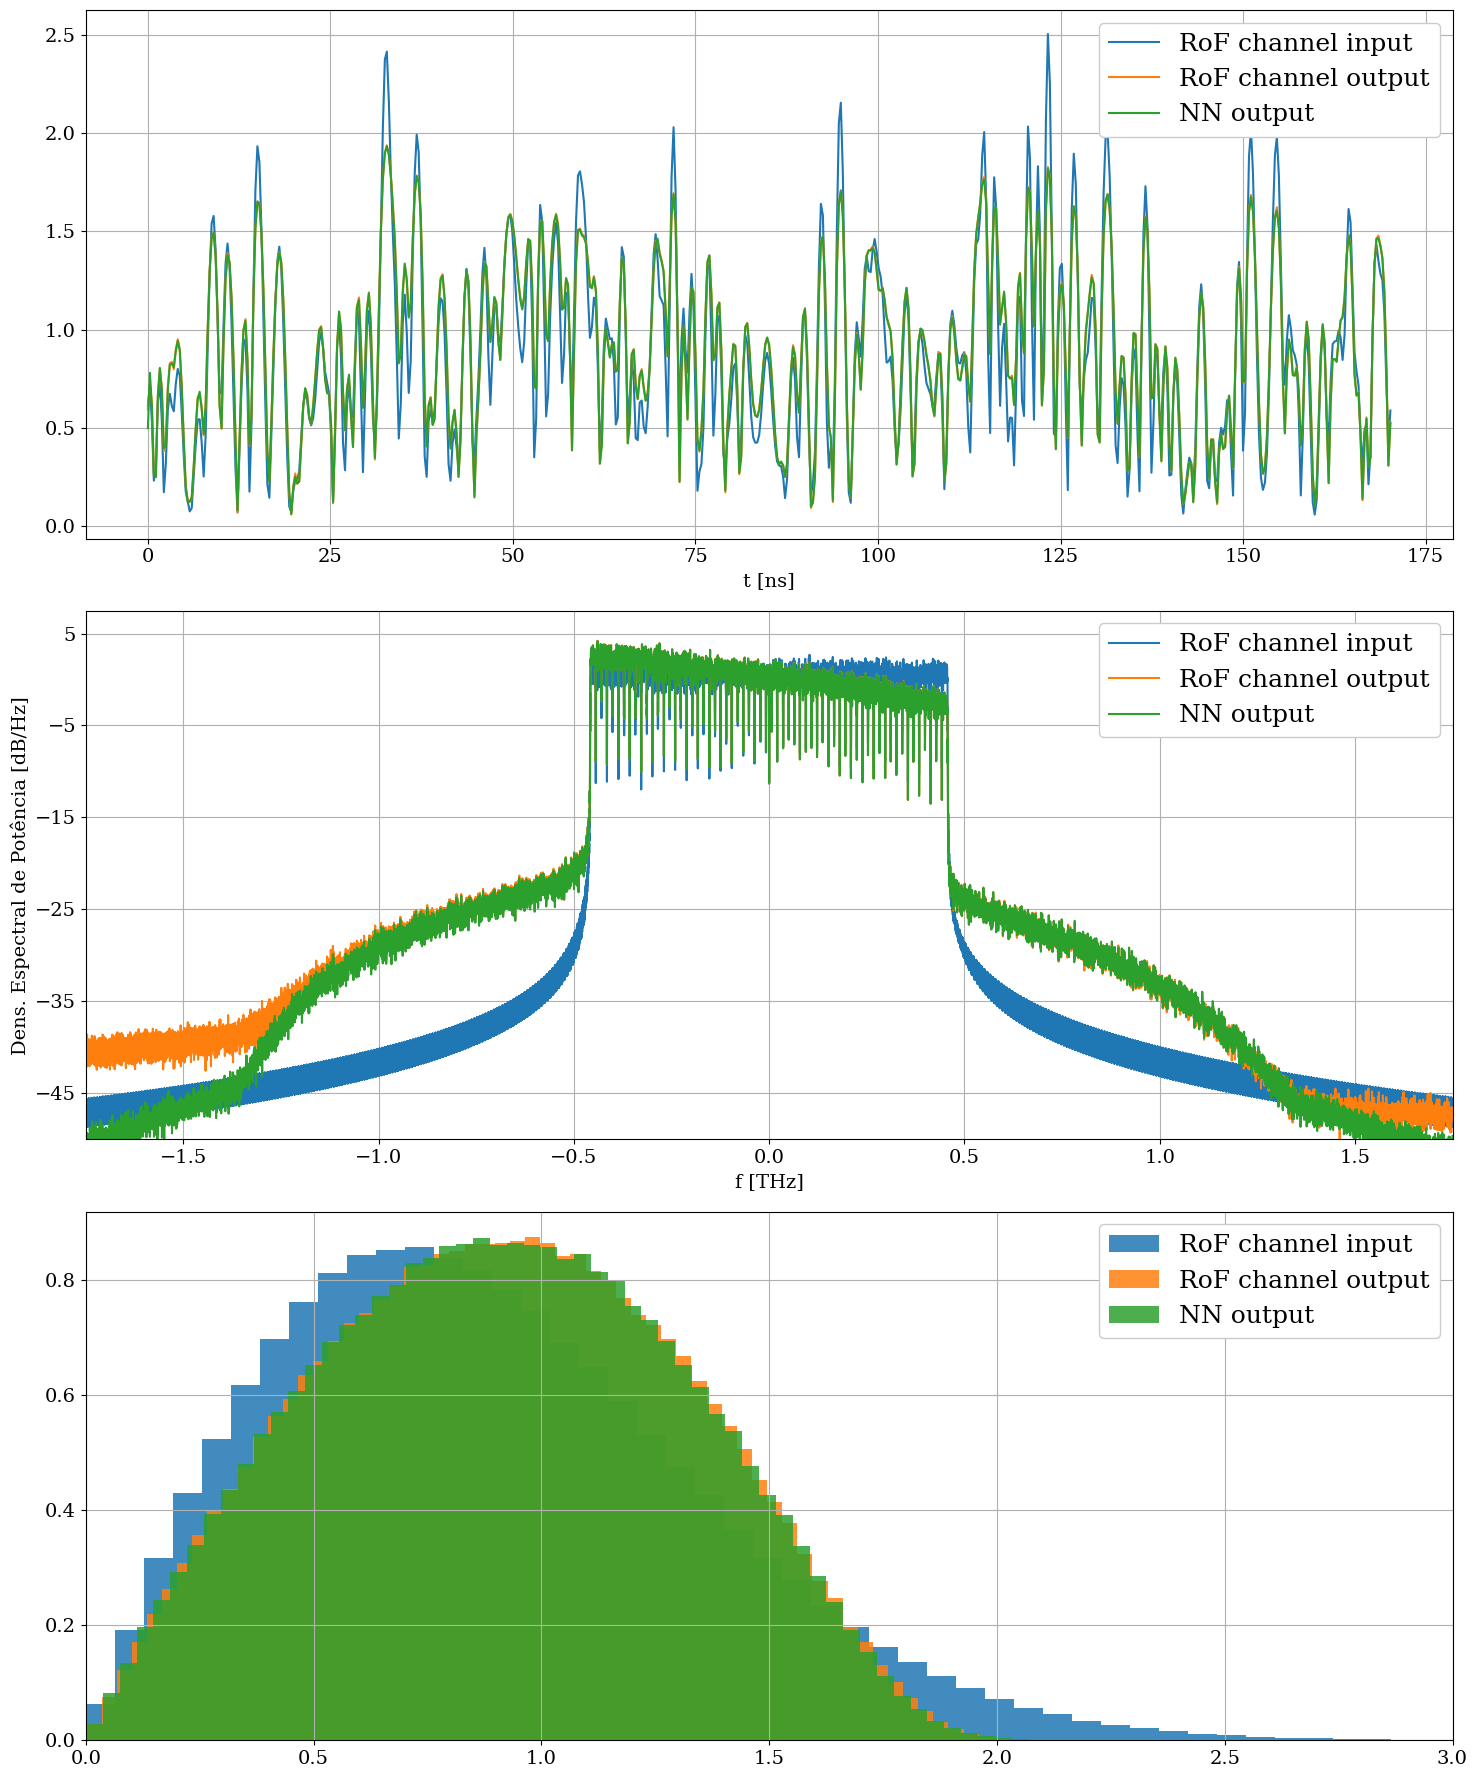

In [1097]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

MSE = 10*th.log10(th.mean(th.abs(sigIn - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), label = "RoF channel output")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sig_nn.cpu().numpy()[indx]), label = "NN output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel output")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "NN output")

axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.75, 1.75)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].hist(th.abs(sig_nn).detach().cpu().numpy(), density = True, bins = 64, label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [1067]:
paramTrain = parameters()

N = 200000
paramTrain.num_feat = 5
paramTrain.N1 = 10 #12  #265
paramTrain.N2 = 150 # 324 #20 

paramTrain.divByL = 25
paramTrain.trainTestFrac = 0.75
paramTrain.batch_size = 100
paramTrain.shuffle = False
paramTrain.includeMemory = includeMemory
paramTrain.Ntaps = 8
paramTrain.augment = True

paramTrain.device = device
paramTrain.lr = 6e-4
paramTrain.epochs = 500
paramTrain.activation = "relu"
paramTrain.pgrsBar = True
paramTrain.directLearn = False

DPD_indirectLearn, trainLoss, testLoss = NN_training(sigIn[0:N], sigRef[0:N], paramTrain)

  0%|          | 0/500 [00:00<?, ?it/s]

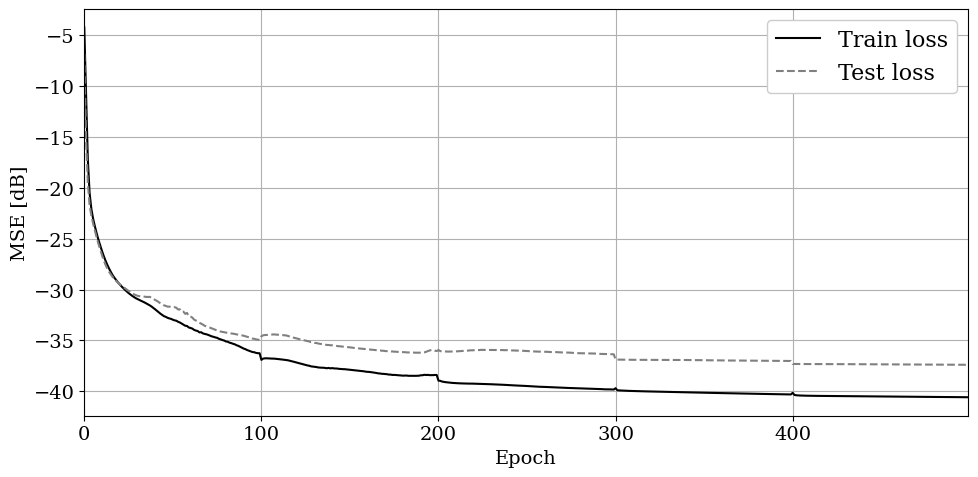

In [1068]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramTrain.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [1069]:
if includeMemory:
    sig_nn = fitFilterNN(sigIn, DPD_indirectLearn, paramTrain.Ntaps, 1, 4000, augment = paramTrain.augment)
else:
    with th.no_grad():
        sig_nn = th.view_as_complex(DPD_indirectLearn(th.view_as_real(sigIn).to(th.float32)))

MSE = -35.005 dB


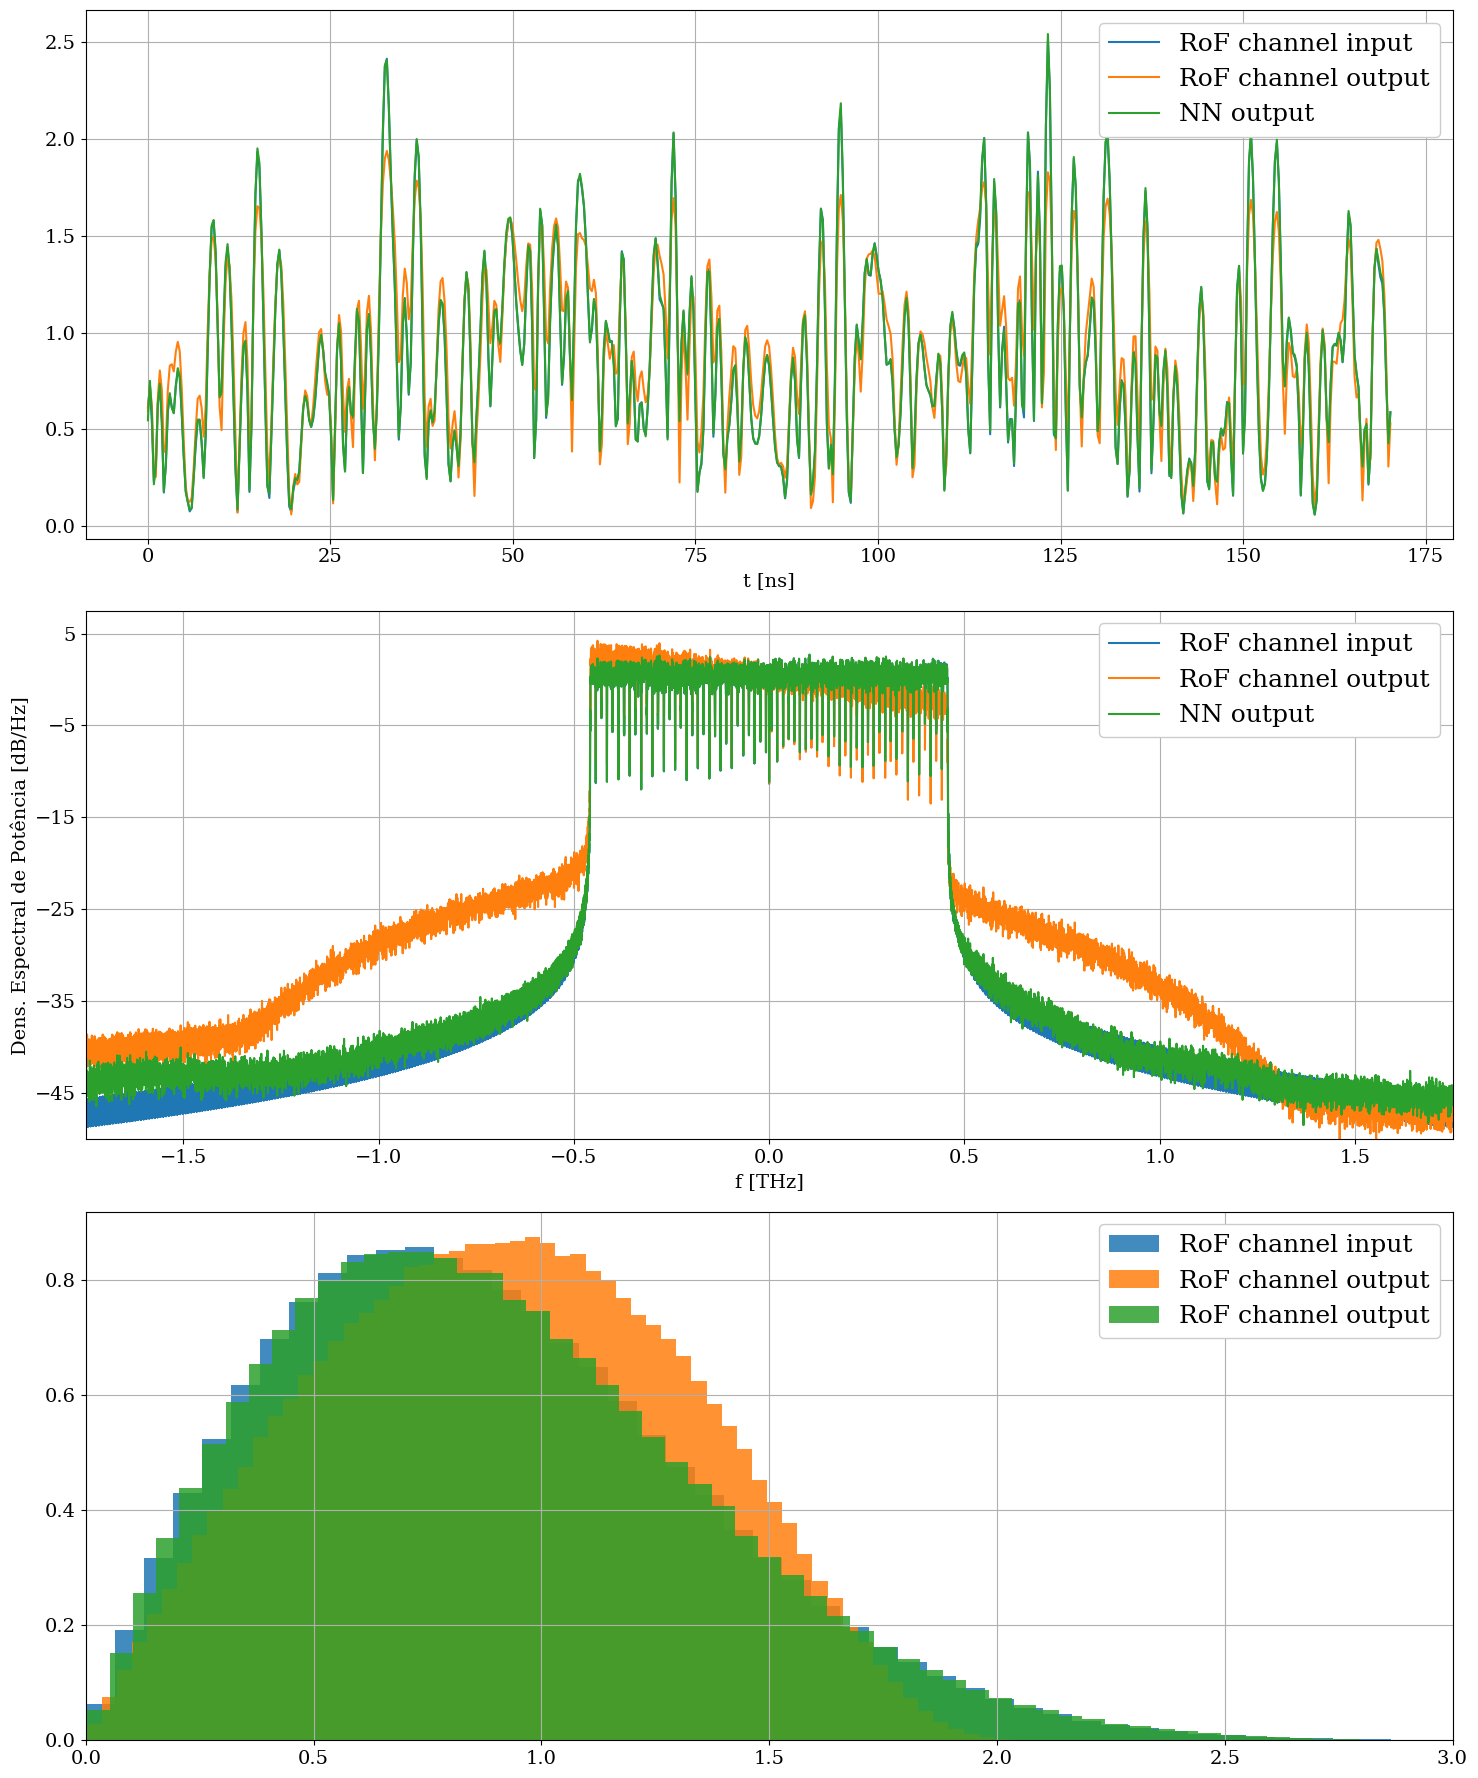

In [1070]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

MSE = 10*th.log10(th.mean(th.abs(sigRef - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), label = "RoF channel output")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sig_nn.cpu().numpy()[indx]), label = "NN output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel output")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "NN output")

axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.75, 1.75)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].hist(th.abs(sig_nn).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

### 5 - Arquitetura de Aprendizado Direto (DLA)

In [1098]:
paramTrain = parameters()

N = 200000 #len(sigRef)
paramTrain.num_feat = 5
paramTrain.N1 = 10
paramTrain.N2 = 150

paramTrain.divByL = 25
paramTrain.trainTestFrac = 0.75
paramTrain.batch_size = 100
paramTrain.shuffle = False
paramTrain.includeMemory = includeMemory
paramTrain.Ntaps = 8
paramTrain.augment = True

paramTrain.device = device
paramTrain.lr = 6e-4
paramTrain.epochs = 500
paramTrain.activation = "relu"
paramTrain.pgrsBar = True
paramTrain.directLearn = True

DPD_directLearn, trainLoss, testLoss = NN_training(sigIn[0:N], sigRef[0:N], paramTrain, RoFChannel_model)

  0%|          | 0/500 [00:00<?, ?it/s]

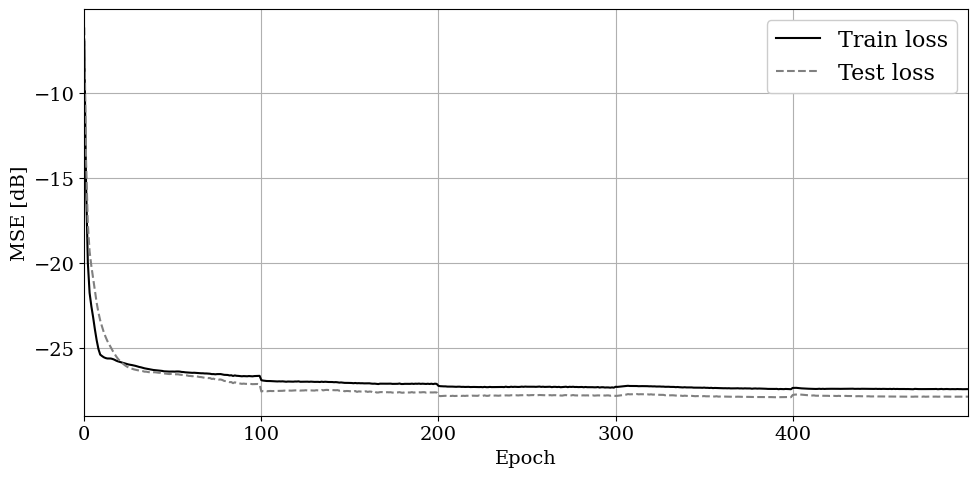

In [1099]:
fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(10*np.log10(trainLoss), color = "k", label = "Train loss")
axs.plot(10*np.log10(testLoss), "--", color = "gray", label = "Test loss")

axs.set_xlim(0, paramTrain.epochs - 1)
axs.set_ylabel("MSE [dB]")
axs.set_xlabel("Epoch")
axs.grid()
axs.legend(fontsize = 16, framealpha = 1)
plt.tight_layout()

In [1100]:
if includeMemory:
    sig_nn = fitFilterNN(sigRef, DPD_directLearn, paramTrain.Ntaps, 1, 4000, augment = paramTrain.augment)
    sig_nn = fitFilterNN(sig_nn, RoFChannel_model, paramTrain.Ntaps, 1, 4000)
else:
    with th.no_grad():
        sig_nn = th.view_as_complex(DPD_directLearn(th.view_as_real(sigIn).to(th.float32)))

MSE = -28.528 dB


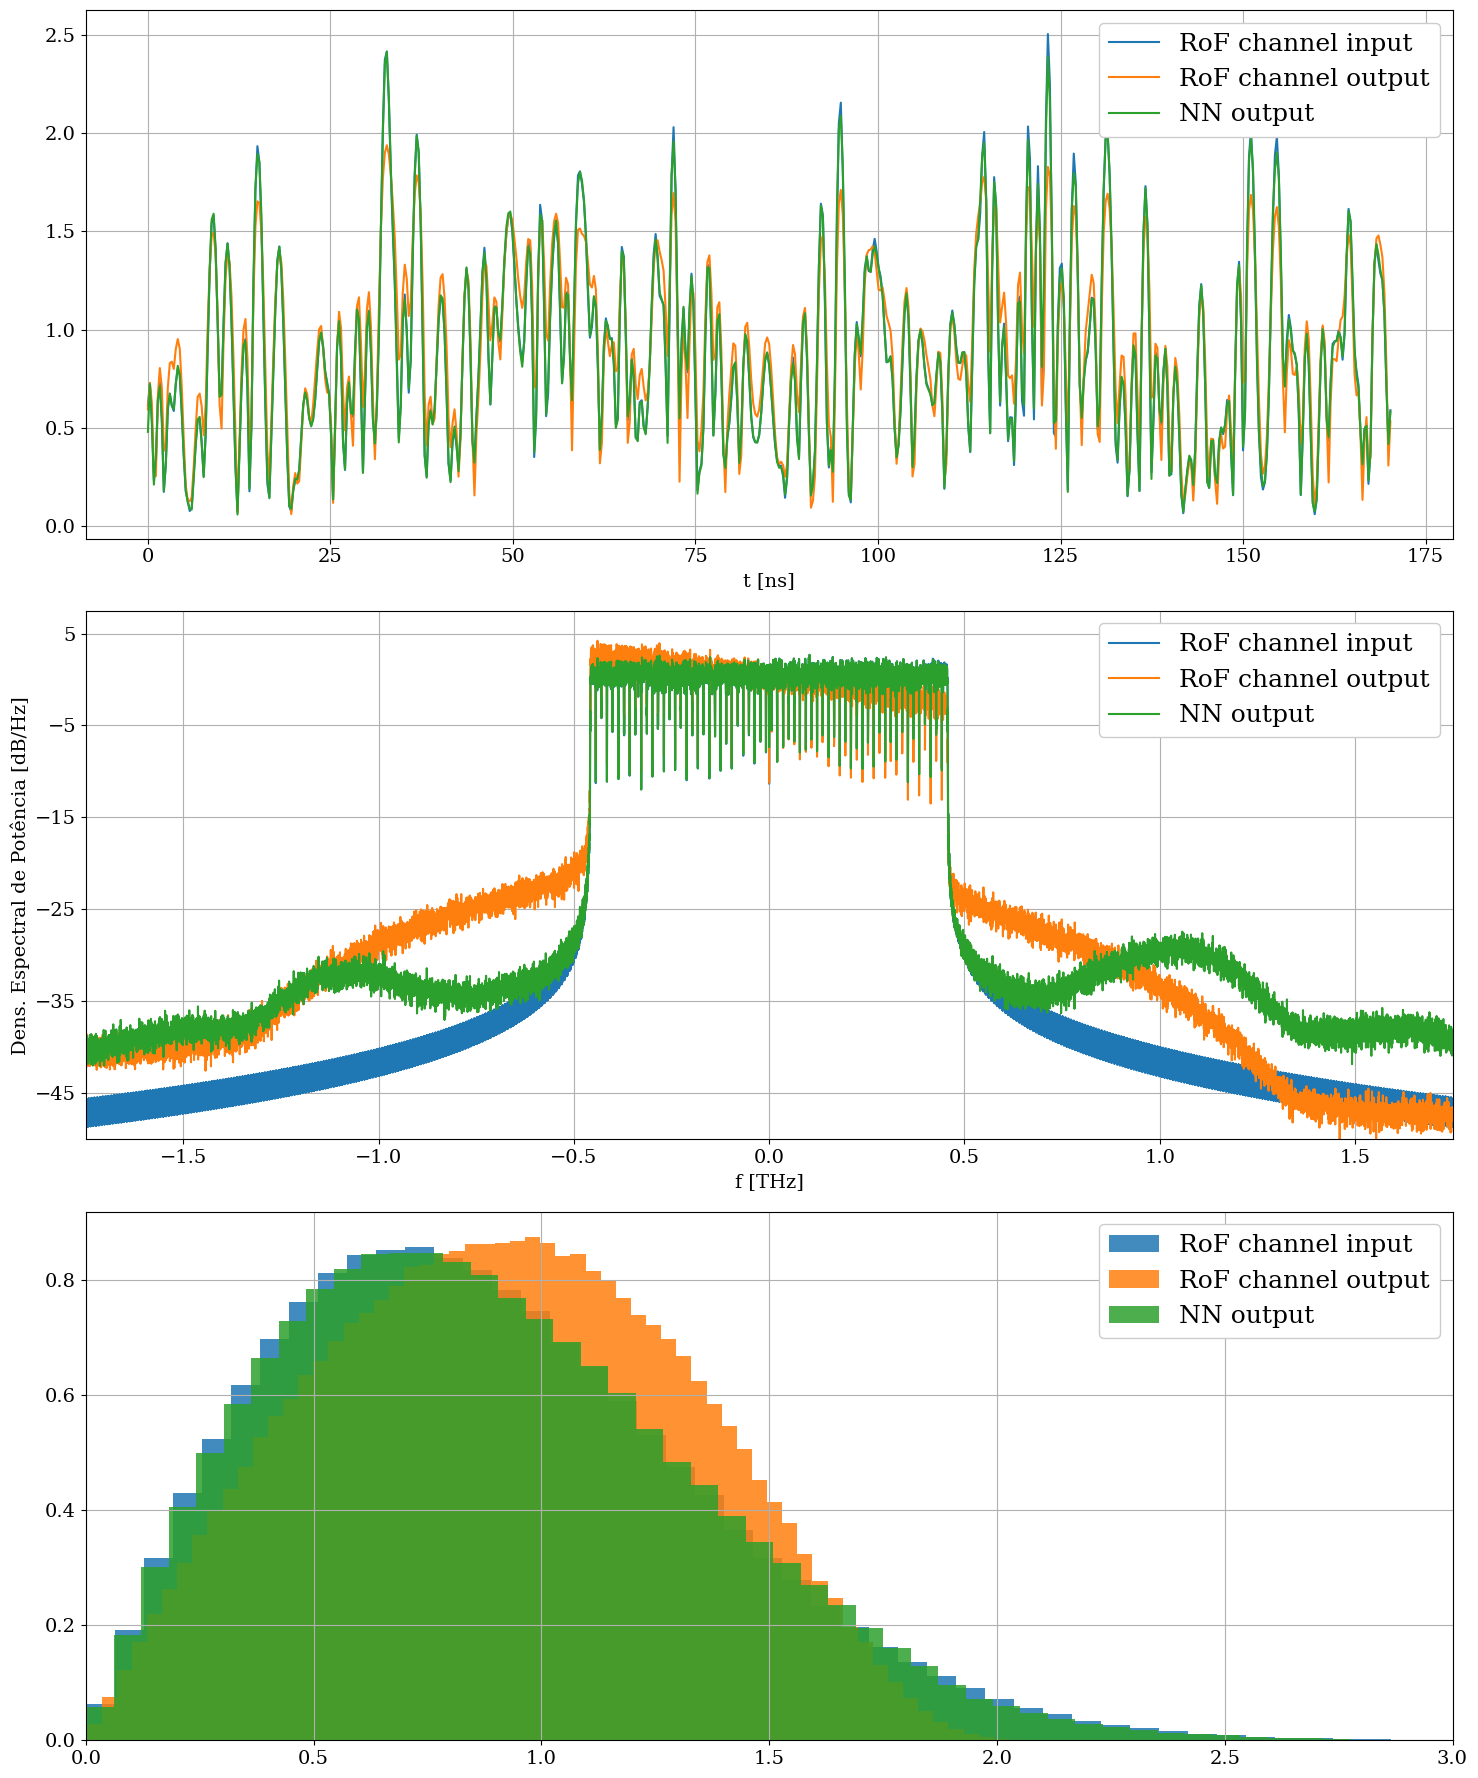

In [1101]:
indx = np.arange(0, int(10000*SpS_nn/SpS))
fig, axs = plt.subplots(3, 1, figsize = (15, 18))
t = th.arange(0, len(sigRef), dtype=th.float64, device=device)*(1/Fs)*(SpS/SpS_nn)

MSE = 10*th.log10(th.mean(th.abs(sigRef - sig_nn)**2))
print(f"MSE = {MSE:.3f} dB")

axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigRef.cpu().numpy()[indx]), label = "RoF channel input")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sigIn.cpu().numpy()[indx]), label = "RoF channel output")
axs[0].plot(t.cpu().numpy()[indx]*1e9, np.abs(sig_nn.cpu().numpy()[indx]), label = "NN output")

axs[1].psd(sigRef.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel input")
axs[1].psd(sigIn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "RoF channel output")
axs[1].psd(sig_nn.detach().cpu().numpy(), Fs = (SpS_nn/SpS)*Fs/1e9, NFFT = 16*1024, sides = 'twosided', label = "NN output")

axs[0].set_xlabel("t [ns]")
axs[0].grid()
axs[0].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[1].set_xlabel("f [THz]")
axs[1].set_ylabel("Dens. Espectral de Potência [dB/Hz]")
axs[1].set_xlim(-1.75, 1.75)
axs[1].set_ylim(-50)
axs[1].grid(True)
axs[1].legend(framealpha = 1, fontsize = 18, loc = "upper right")

axs[2].hist(th.abs(sigRef).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel input', alpha = 0.85)
axs[2].hist(th.abs(sigIn).detach().cpu().numpy(), density = True, bins = 64, label = 'RoF channel output', alpha = 0.85)
axs[2].hist(th.abs(sig_nn).detach().cpu().numpy(), density = True, bins = 64, label = 'NN output', alpha = 0.85)
axs[2].set_xlim(0, 3)
axs[2].grid()
axs[2].legend(framealpha = 1, fontsize = 18, loc = "upper right")

plt.tight_layout()
plt.show()

### 6 DPD test

In [1102]:
device = 'cuda'

# Parâmetros de modulação
modOrder = 64
modType  = 'qam'
Rb = 5e9    
SpS = 64
SpS_nn = 4

# OFDM signal parameters
paramOFDM = parameters()
paramOFDM.Nfft = 1024
paramOFDM.Np   = 64
paramOFDM.G    = 32
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS_nn
paramOFDM.pilotCarriers = np.linspace(0, paramOFDM.Nfft-1, paramOFDM.Np, dtype=np.int64) # Pilot subcarriers
Ns = paramOFDM.Nfft - paramOFDM.Np     # Núm. de subportadoras de informação

Rs = Rb / ( Ns/(paramOFDM.Nfft + paramOFDM.G) * np.log2(modOrder) )    # Taxa de transmissão de símbolos
Fs = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
batchSize = 1000//(int(paramOFDM.Nfft/128))
bits = th.randint(2, size = (batchSize*(Ns - 1), int(np.log2(modOrder))), dtype = th.float32, device = device)

symbTx = modulateGray(bits.view(-1,).type(th.int64), modOrder, modType)    
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [1103]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

# ILA
DPD_indirectLearn.eval()
if includeMemory:
    sigTx_DPD_ILA = fitFilterNN(sigTx, DPD_indirectLearn, paramTrain.Ntaps, 1, 4000, augment = paramTrain.augment)
else:
    with th.no_grad():
        sigTx_DPD_ILA = th.view_as_complex(DPD_indirectLearn(th.view_as_real(sigTx)))

# DLA
DPD_directLearn.eval()
if includeMemory:
    sigTx_DPD_DLA = fitFilterNN(sigTx, DPD_directLearn, paramTrain.Ntaps, 1, 4000, augment = paramTrain.augment)
else:
    with th.no_grad():
        sigTx_DPD_DLA = th.view_as_complex(DPD_directLearn(th.view_as_real(sigTx)))

In [1104]:
numtaps = 4096
h_dpd = th.tensor(firwin(numtaps, 2*Rs, fs=Fs)).to(device)

# ILA
sigTx_DPD_ILA = upsample(sigTx_DPD_ILA.reshape(-1,1), SpS//SpS_nn).reshape(-1,) 
sigTx_DPD_ILA = firFilter(sigTx_DPD_ILA, h_dpd)

# DLA
sigTx_DPD_DLA = upsample(sigTx_DPD_DLA.reshape(-1,1), SpS//SpS_nn).reshape(-1,) 
sigTx_DPD_DLA = firFilter(sigTx_DPD_DLA, h_dpd)

In [1105]:
t = th.arange(0, len(sigTx_DPD_DLA), dtype=th.float64, device=device)*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

#### 6.1 Sinal RF

In [1106]:
sigTx_RF_ILA = th.real( sigTx_DPD_ILA * th.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_ILA = np.sqrt(dBm2W(paramRF.Pin_RF))*pnorm(sigTx_RF_ILA)

sigTx_RF_DLA = th.real( sigTx_DPD_DLA * th.exp(1j*2*pi*paramRF.fc_e*t) )
sigTx_RF_DLA = np.sqrt(dBm2W(paramRF.Pin_RF))*pnorm(sigTx_RF_DLA)

#### 6.2 Sinal óptico

In [1107]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*th.ones(sigTx_RF_ILA.shape, device = device)
sigTxo_ILA = mzm(Ai, sigTx_RF_ILA, paramMZM)

numtaps = 4096
hopt_tx = th.tensor(firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)).to(device)
sigTxo_ILA  = th.sqrt(signal_power(sigTxo_ILA))*pnorm(firFilter(hopt_tx, sigTxo_ILA))

sigRxo_ILA = linearFiberChannel(sigTxo_ILA, paramChannel)

In [1108]:
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*th.ones(sigTx_RF_DLA.shape, device = device)
sigTxo_DLA = mzm(Ai, sigTx_RF_DLA, paramMZM)

numtaps = 4096
hopt_tx = th.tensor(firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)).to(device)
sigTxo_DLA  = th.sqrt(signal_power(sigTxo_DLA))*pnorm(firFilter(hopt_tx, sigTxo_DLA))

sigRxo_DLA = linearFiberChannel(sigTxo_DLA, paramChannel)

#### 6.3 Sinal elétrico (fotocorrente)

In [1109]:
I_Rx_ILA = photodiode(sigRxo_ILA, paramPD)
I_Rx_ILA = pnorm(I_Rx_ILA)
I_Rx_ILA -= I_Rx_ILA.mean()

In [1110]:
I_Rx_DLA = photodiode(sigRxo_DLA, paramPD)
I_Rx_DLA = pnorm(I_Rx_DLA)
I_Rx_DLA -= I_Rx_DLA.mean()

#### 6.4 Sinal elétrico pós-FPF

In [1111]:
# Filtro passa-faixas
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = th.tensor(firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)).to(device)

I_RF_ILA = firFilter(hbp_RF, I_Rx_ILA)
I_RF_DLA = firFilter(hbp_RF, I_Rx_DLA)

#### 6.5 Sinal elétrico pós-PA

In [1112]:
sigRx_ILA = hilbert(I_RF_ILA)*th.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_ILA = np.sqrt(dBm2W(paramRF.Pin_PA))*pnorm(sigRx_ILA)
sigRx_ILA = powerAmplifier(sigRx_ILA)

sigRx_PA_DPD_ILA = sigRx_ILA.clone().detach()

numtaps = 4096
hlp = th.tensor(firwin(numtaps, Rs/1.5, fs = Fs)).to(device)
sigRx_ILA = firFilter(hlp, sigRx_ILA)

delay = finddelay(sigRx_ILA, sigTx_DPD_ILA)
sigRx_ILA = th.roll(sigRx_ILA, -delay)

rot = th.mean(sigTx_DPD_ILA/sigRx_ILA)
sigRx_ILA = rot/th.abs(rot)*sigRx_ILA

In [1113]:
sigRx_DLA = hilbert(I_RF_DLA)*th.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx_DLA = np.sqrt(dBm2W(paramRF.Pin_PA))*pnorm(sigRx_DLA)
sigRx_DLA = powerAmplifier(sigRx_DLA)

sigRx_PA_DPD_DLA = sigRx_DLA.clone().detach()

numtaps = 4096
hlp = th.tensor(firwin(numtaps, Rs/1.5, fs = Fs)).to(device)
sigRx_DLA = firFilter(hlp, sigRx_DLA)

delay = finddelay(sigRx_DLA, sigTx_DPD_DLA)
sigRx_DLA = th.roll(sigRx_DLA, -delay)

rot = th.mean(sigTx_DPD_DLA/sigRx_DLA)
sigRx_DLA = rot/th.abs(rot)*sigRx_DLA

#### Performance

In [1114]:
# Parâmetros da decimação
paramDec = parameters()
paramDec.SpS_in  = SpS
paramDec.SpS_out = 1

symbRx_OFDM = decimate(sigRx_ILA, paramDec).ravel()
symbRx_DPD_ILA = demodulateOFDM(symbRx_OFDM, paramOFDM)

symbRx_OFDM = decimate(sigRx_DLA, paramDec).ravel()
symbRx_DPD_DLA = demodulateOFDM(symbRx_OFDM, paramOFDM)

BER = 0.00000 
SNR = 30.559 dB 
EVM = -30.568 dB


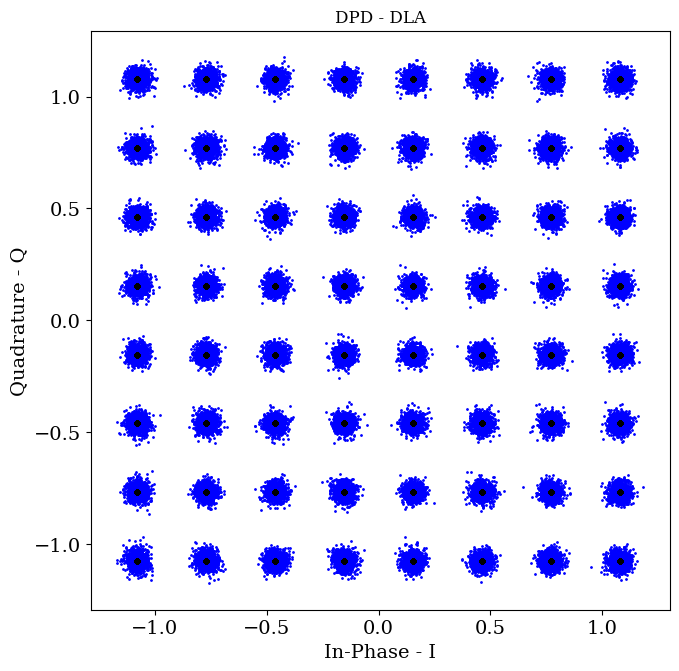

In [1115]:
discard = 500
index = th.arange(discard, len(symbTx) - discard)
BER, SER, SNR = fastBERcalc(symbRx_DPD_DLA[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx_DPD_DLA.detach().cpu().numpy(), modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_DLA = pnorm(symbRx_DPD_DLA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx_DPD_DLA.real.cpu().numpy(), symbRx_DPD_DLA.imag.cpu().numpy(), "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real.cpu().numpy(), symbTx.imag.cpu().numpy(), "o", color = "k", ms = 3, label = "SymbTx")
axs.set_title(f"DPD - DLA", fontsize = 12)
axs.set_ylabel("Quadrature - Q")
axs.set_xlabel("In-Phase - I")
plt.axis("square")
plt.tight_layout()

BER = 0.00000 
SNR = 29.433 dB 
EVM = -29.442 dB


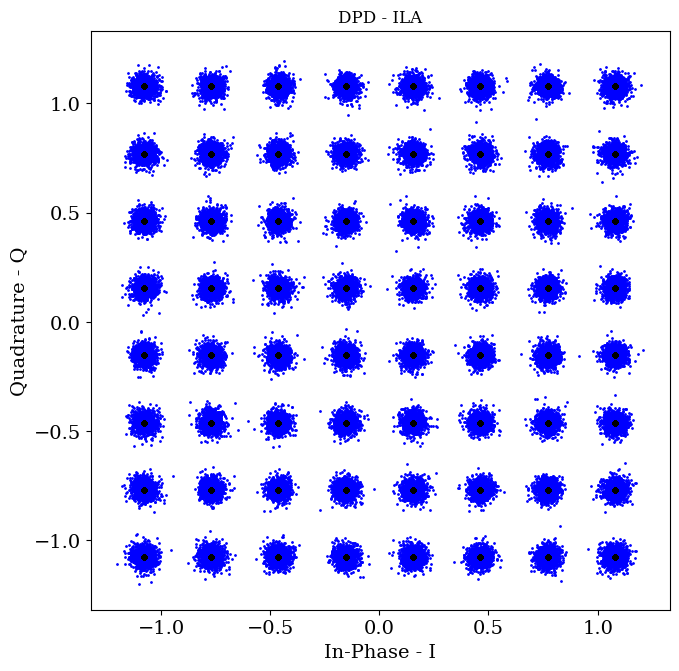

In [1116]:
discard = 500
index = th.arange(discard, len(symbTx) - discard)
BER, SER, SNR = fastBERcalc(symbRx_DPD_ILA[index], symbTx[index], modOrder, modType)

EVM = 10*np.log10(calcEVM(symbRx_DPD_ILA.detach().cpu().numpy(), modOrder, modType))

print(f"BER = {BER[0]:.5f} \nSNR = {SNR[0]:.3f} dB \nEVM = {EVM[0]:.3f} dB")

# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx_DPD_ILA = pnorm(symbRx_DPD_ILA)

fig, axs = plt.subplots(figsize = (7, 7))
axs.plot(symbRx_DPD_ILA.real.cpu().numpy(), symbRx_DPD_ILA.imag.cpu().numpy(), "o", color = "b", ms = 1, label = "SymbRx")
axs.plot(symbTx.real.cpu().numpy(), symbTx.imag.cpu().numpy(), "o", color = "k", ms = 3, label = "SymbTx")
axs.set_title(f"DPD - ILA", fontsize = 12)
axs.set_ylabel("Quadrature - Q")
axs.set_xlabel("In-Phase - I")
plt.axis("square")
plt.tight_layout()

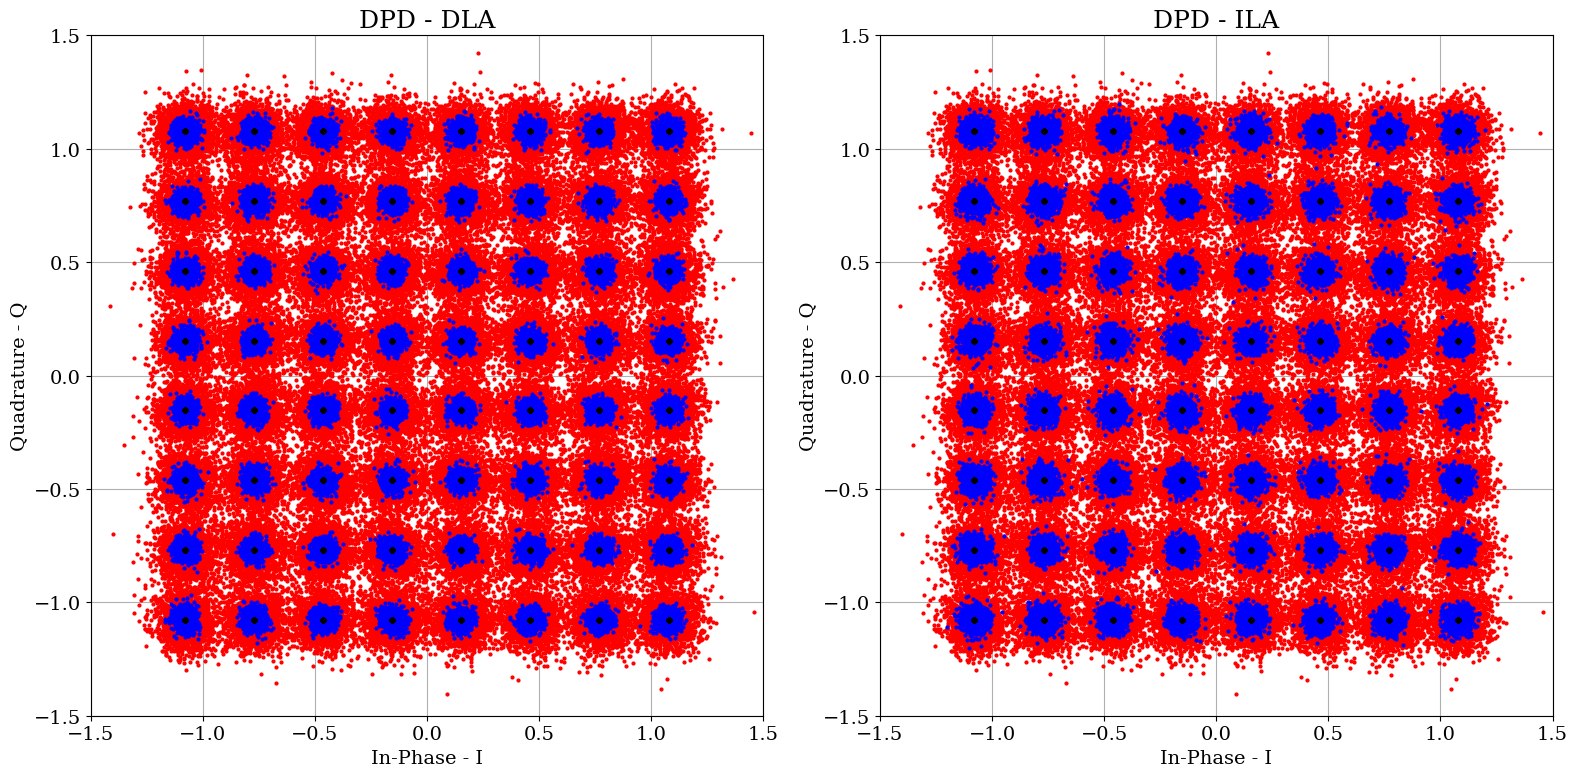

In [1117]:
# Normalização para o plot
symbTx = pnorm(symbTx)
symbRx = pnorm(symbRx)

fig, axs = plt.subplots(1, 2, figsize = (16, 8))

axs[0].plot(symbRx.real.cpu().numpy(), symbRx.imag.cpu().numpy(), "o", color = "r", ms = 2, label = "Sem DPD")
axs[0].plot(symbRx_DPD_DLA.real.cpu().numpy(), symbRx_DPD_DLA.imag.cpu().numpy(), "o", color = "b", ms = 2, label = "Com DPD")
axs[0].plot(symbTx.real.cpu().numpy(), symbTx.imag.cpu().numpy(), "o", color = "k",  ms = 3, label = "SymbTx")
axs[0].set_title("DPD - DLA", fontsize = 18)
axs[0].set_ylabel("Quadrature - Q")
axs[0].set_xlabel("In-Phase - I")
axs[0].set_xlim(-1.5, 1.5)
axs[0].set_ylim(-1.5, 1.5)
axs[0].grid()

axs[1].plot(symbRx.real.cpu().numpy(), symbRx.imag.cpu().numpy(), "o", color = "r", ms = 2, label = "Sem DPD")
axs[1].plot(symbRx_DPD_ILA.real.cpu().numpy(), symbRx_DPD_ILA.imag.cpu().numpy(), "o", color = "b", ms = 2, label = "Com DPD")
axs[1].plot(symbTx.real.cpu().numpy(), symbTx.imag.cpu().numpy(), "o", color = "k",  ms = 3, label = "SymbTx")
axs[1].set_title("DPD - ILA", fontsize = 18)
axs[1].set_ylabel("Quadrature - Q")
axs[1].set_xlabel("In-Phase - I")
axs[1].set_xlim(-1.5, 1.5)
axs[1].set_ylim(-1.5, 1.5)
axs[1].grid()

plt.tight_layout()

SNR improvement mean: 10.044 dB


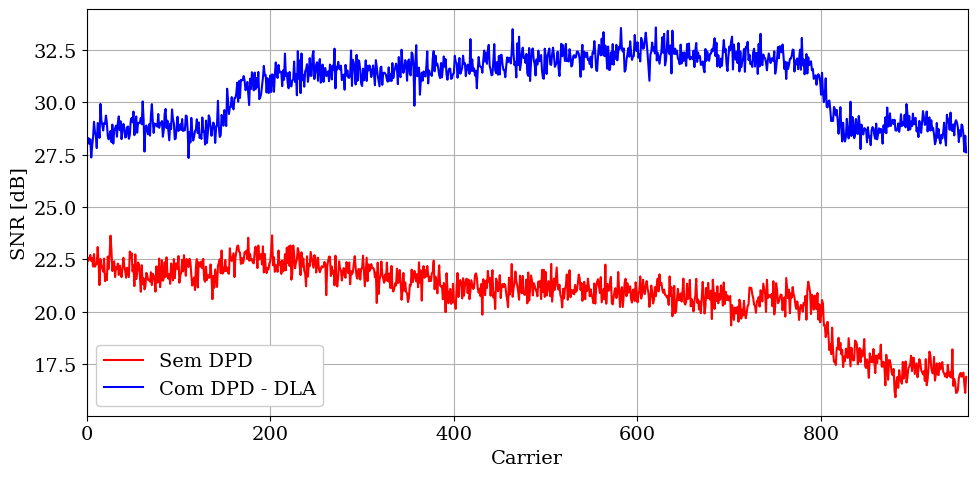

In [1118]:
SNR_per_carrier_DLA = calcSNR_per_carrier(symbTx.detach().cpu().numpy(), symbRx_DPD_DLA.detach().cpu().numpy(), Ns - 1)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(SNR_per_carrier, color = "r", label = "Sem DPD")
axs.plot(SNR_per_carrier_DLA, color = "b", label = "Com DPD - DLA")
axs.set_xlim(0, Ns)
axs.set_ylabel("SNR [dB]")
axs.set_xlabel("Carrier")
axs.legend(framealpha = 1, fontsize = 14)
axs.grid()
plt.tight_layout()

print(f"SNR improvement mean: {np.mean(SNR_per_carrier_DLA - SNR_per_carrier):.3f} dB")

SNR improvement mean: 8.896 dB


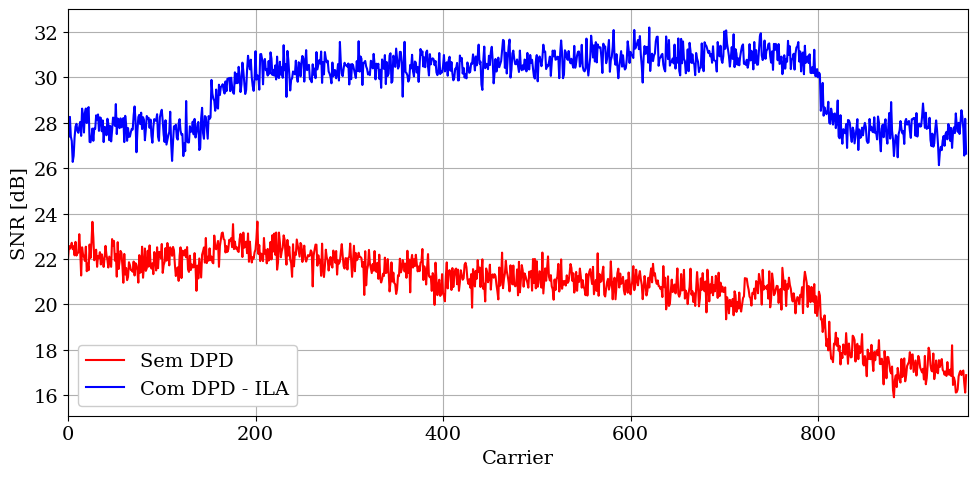

In [1119]:
SNR_per_carrier_ILA = calcSNR_per_carrier(symbTx.detach().cpu().numpy(), symbRx_DPD_ILA.detach().cpu().numpy(), Ns - 1)

fig, axs = plt.subplots(figsize = (10, 5))
axs.plot(SNR_per_carrier, color = "r", label = "Sem DPD")
axs.plot(SNR_per_carrier_ILA, color = "b", label = "Com DPD - ILA")
axs.set_xlim(0, Ns)
axs.set_ylabel("SNR [dB]")
axs.set_xlabel("Carrier")
axs.legend(framealpha = 1, fontsize = 14)
axs.grid()
plt.tight_layout()

print(f"SNR improvement mean: {np.mean(SNR_per_carrier_ILA - SNR_per_carrier) :.3f} dB")

In [1120]:
freq, P_sigTx            = welch(pnorm(sigTx).detach().cpu().numpy(), fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA         = welch(pnorm(sigRx_PA).detach().cpu().numpy()[0::SpS//SpS_nn], fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_DLA = welch(pnorm(sigRx_PA_DPD_DLA).detach().cpu().numpy()[0::SpS//SpS_nn], fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)
freq, P_sigRx_PA_DPD_ILA = welch(pnorm(sigRx_PA_DPD_ILA).detach().cpu().numpy()[0::SpS//SpS_nn], fs = SpS_nn*Rs, nfft = 16*1024, return_onesided = False)

SigTx - ACLR = -33.429 dB
SigRx PA w/o DPD - ACLR = -24.826 dB
SigRx PA w DPD-ILA - ACLR = -27.633 dB
SigRx PA w DPD-DLA - ACLR = -27.922 dB


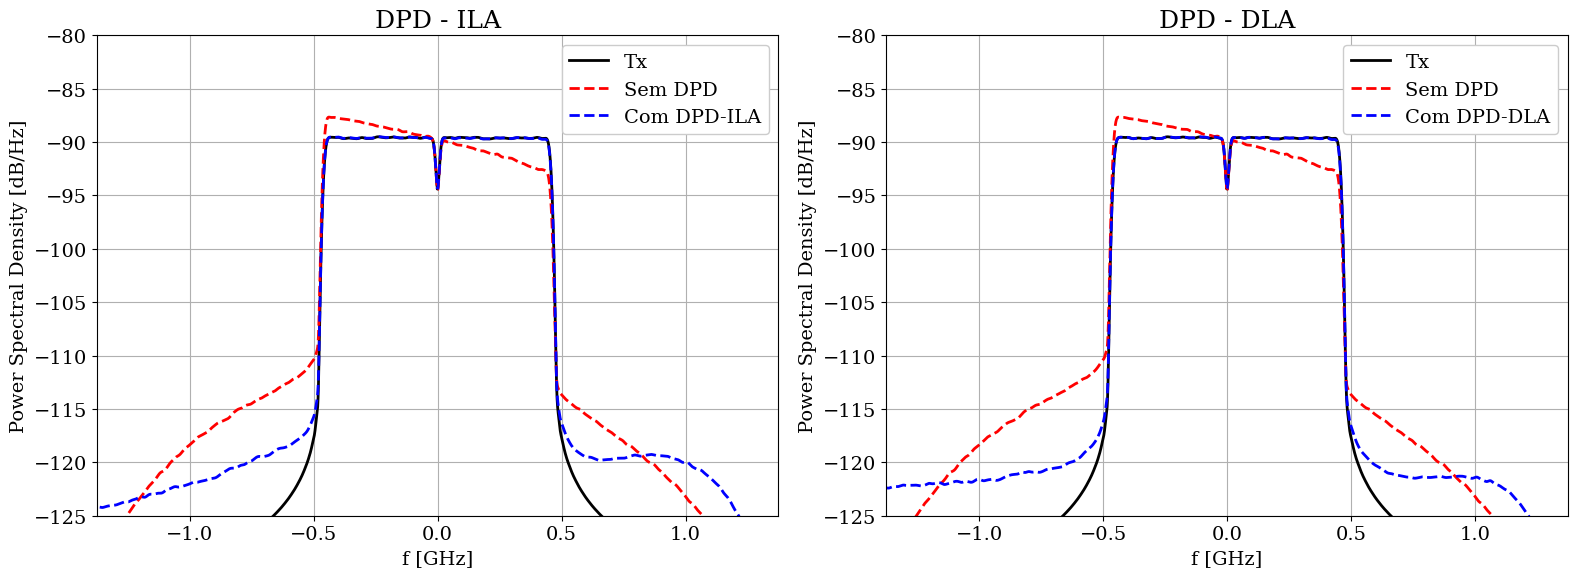

In [1121]:
fig, axs = plt.subplots(1, 2, figsize = (16, 6))

axs[0].plot(freq/1e9, 10*np.log10(P_sigTx), color = "k", ls = "-", lw = 2, label = "Tx")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA), color = "r", ls = "--", lw = 2, label = "Sem DPD")
axs[0].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_ILA), color = "b", ls = "--", lw = 2, label = r"Com DPD-ILA")
axs[0].set_title("DPD - ILA", fontsize = 18)
axs[0].set_xlim(-1.5*Rs/1e9, 1.5*Rs/1e9)
axs[0].set_ylim(-125, -80)
axs[0].set_xlabel("f [GHz]")
axs[0].set_ylabel("Power Spectral Density [dB/Hz]")
axs[0].legend(fontsize = 14, framealpha = 1)
axs[0].grid()

axs[1].plot(freq/1e9, 10*np.log10(P_sigTx), color = "k", ls = "-", lw = 2, label = "Tx")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA), color = "r", ls = "--", lw = 2, label = "Sem DPD")
axs[1].plot(freq/1e9, 10*np.log10(P_sigRx_PA_DPD_DLA), color = "b", ls = "--", lw = 2, label = r"Com DPD-DLA")
axs[1].set_title("DPD - DLA", fontsize = 18)
axs[1].set_xlim(-1.5*Rs/1e9, 1.5*Rs/1e9)
axs[1].set_ylim(-125, -80)
axs[1].set_xlabel("f [GHz]")
axs[1].set_ylabel("Power Spectral Density [dB/Hz]")
axs[1].legend(fontsize = 14, framealpha = 1)
axs[1].grid()

plt.tight_layout()

print(f"SigTx - ACLR = {calcACLR(P_sigTx, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w/o DPD - ACLR = {calcACLR(P_sigRx_PA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-ILA - ACLR = {calcACLR(P_sigRx_PA_DPD_ILA, freq, 0.5e9):.3f} dB")
print(f"SigRx PA w DPD-DLA - ACLR = {calcACLR(P_sigRx_PA_DPD_DLA, freq, 0.5e9):.3f} dB")